In [1]:
import os
import glob
import numpy as np
import altair as alt
import polars as pl
import pandas as pd
import shap
from catboost import CatBoostRegressor, Pool


from birds.source_data.nabbp import LookupTables #, DataTables
#from birds.source_data.iucn import IUCNDataTables
from birds.settings import load_settings, get_relative_path


from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib


from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
#from sklearn.dummy import DummyRegressor
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

In [3]:
settings = load_settings()
lookup = LookupTables()

In [4]:
modelpath = get_relative_path(settings.model_path)
print(f"Model path: {modelpath}")

Model path: ../data/models


In [5]:
def load_agg_data_files(nfiles):
    data_dir = get_relative_path(get_relative_path(settings.augmented_band_agg))
    print(data_dir)

    all_files = sorted(glob.glob(os.path.join(data_dir, "nabbp_band_agg_*.parquet")))

    if nfiles > 0:
        all_files = all_files[-nfiles:]
    
    print(f"Loading {len(all_files)} files from {data_dir}")
    df = pl.concat([pl.read_parquet(f) for f in all_files])
    return df


df = load_agg_data_files(99)

../data/augmented_data/band_agg
Loading 57 files from ../data/augmented_data/band_agg


In [6]:
df.head()

banding_record_id,banding_band,banding_date,banding_day,banding_month,banding_year,banding_species_id,banding_iso_country,banding_iso_subdivision,banding_band_type_code,banding_bird_status,banding_age_code,banding_sex_code,banding_event_type,banding_band_status_code,banding_extra_info_code,banding_lat_dd,banding_lon_dd,banding_coordinates_precision_code,banding_permit,banding_record_source,num_events,last_event_date,last_how_obtained_code,last_who_obtained_code,last_reporting_method,last_present_condition,last_lat_dd,last_lon_dd,last_iso_country,last_iso_subdivision,event_days_span,first_to_last_km,num_event_days_span
i64,str,date,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,i64,date,i64,i64,i64,i64,f64,f64,str,str,i64,f64,i64
-42574156,"""B58235077397""",2005-07-29,29,7,2005,1691,"""CA""","""CA-ON""","""1""","""3""","""1""","""5""","""B""","""0""","""00""",55.5,-83.5,"""60.0""","""P8832232""","""B""",1,2005-10-13,1,21,6,3,52.41667,-109.25,"""CA""","""CA-SK""",76,1708.745971,76
-16205515,"""B17815174927""",2017-07-15,15,7,2017,1710,"""CA""","""CA-NU""","""41""","""3""","""1""","""5""","""B""","""0""","""00""",67.5,-101.5,"""60.0""","""P7837928""","""B""",1,2018-12-08,1,21,7,5,34.30495,-91.98342,"""US""","""US-AR""",511,3741.442839,511
19818780,"""B67765371626""",2023-07-19,19,7,2023,1690,"""CA""","""CA-NT""","""9999""","""3""","""5""","""5""","""B""","""0""","""00""",72.5,-124.5,"""60.0""","""P8830613""","""B""",1,2025-04-09,1,21,7,5,50.57183,-112.95173,"""CA""","""CA-AB""",630,2503.432432,630
-42853666,"""B88845010098""",1976-10-29,29,10,1976,1690,"""US""","""US-NE""","""11""","""3""","""1""","""5""","""B""","""0""","""19""",41.5,-96.5,"""60.0""","""P9953434""","""B""",1,1981-12-06,1,20,1,5,40.75,-95.58333,"""US""","""US-IA""",1864,113.357308,1864
-42949648,"""B48495419884""",2003-08-02,2,8,2003,1690,"""US""","""US-AK""","""1""","""3""","""4""","""4""","""B""","""0""","""00""",70.5,-154.5,"""60.0""","""P4741797""","""B""",1,2009-05-22,1,21,61,5,69.41667,-130.25,"""CA""","""CA-NT""",2120,925.553743,2120


In [7]:
cat_cols = [ 'banding_species_id','banding_iso_country', 'banding_iso_subdivision','banding_band_type_code','banding_bird_status',
               'banding_age_code', 'banding_sex_code', 'banding_event_type', 'banding_band_status_code', 'banding_extra_info_code',
               'banding_coordinates_precision_code', 'banding_permit', 'banding_day', 'banding_month', 'banding_year', 'banding_record_source',            
]

banding_columns = [
 'banding_day',
 'banding_month',
 'banding_year',
 'banding_species_id',
 'banding_iso_country',
 'banding_iso_subdivision',
 'banding_band_type_code',
 'banding_bird_status',
 'banding_age_code',
 'banding_sex_code',
 'banding_event_type',
 'banding_band_status_code',
 'banding_extra_info_code',
 'banding_lat_dd',
 'banding_lon_dd',
 'banding_coordinates_precision_code',
 'banding_permit',
 'banding_record_source',
 'event_days_span'
]

#filter df to only banding columns
df_banding = df.select(banding_columns)

In [ ]:
# Try to convert each column to int, fallback to categorical
def convert_column_type(df, col):
    try:
        return df.with_columns(pl.col(col).cast(pl.Int64, strict=True))
    except:
        return df.with_columns(pl.col(col).cast(pl.Categorical))

for col in df_banding.columns:
    df_banding = convert_column_type(df_banding, col)

In [11]:
# drop banding permit column due to high cardinality
df_banding = df_banding.drop('banding_permit')

In [ ]:

# Get categorical columns
categorical_cols = [col for col in df_banding.columns 
                   if df_banding[col].dtype == pl.Categorical]

# One-hot encode with drop_first=True
df_banding_encoded = df_banding.to_dummies(columns=categorical_cols, drop_first=True)

# Add "oh_" prefix to dummy columns
new_column_names = []
for col in df_banding_encoded.columns:
    if any(col.startswith(cat_col + "_") for cat_col in categorical_cols):
        new_column_names.append(f"oh_{col}")
    else:
        new_column_names.append(col)

df_banding_encoded = df_banding_encoded.rename(dict(zip(df_banding_encoded.columns, new_column_names)))

#drop original categorical columns
cols_to_drop = [col for col in categorical_cols if col in df_banding_encoded.columns]
if cols_to_drop:
    df_banding_encoded = df_banding_encoded.drop(columns=cols_to_drop)

In [13]:
# check for non numeric columns
non_numeric_cols = [col for col in df_banding_encoded.columns 
                    if df_banding_encoded[col].dtype not in [pl.Int64, pl.Float64,pl.UInt8]]
print(f"Non-numeric columns after encoding: {non_numeric_cols}")

Non-numeric columns after encoding: []


In [14]:
df_banding_pd = df_banding_encoded.to_pandas()

# remove species ids with less than 10 records.   Needed for reasonable train/test split
species_counts = df_banding_pd['banding_species_id'].value_counts().to_frame().reset_index()
limited_species= species_counts[species_counts['count'] < 10]['banding_species_id'].to_list()
limited_species

df_banding_pd = df_banding_pd[~df_banding_pd['banding_species_id'].isin(limited_species)]

In [15]:
# Split while maintaining species proportions


X = df_banding_pd.drop(columns=['event_days_span'])  # Remove target from features
y = df_banding_pd['event_days_span']


X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,
    stratify=X['banding_species_id'],  # files are split by species_id and were loaded in order ensure distribution across train/test
    random_state=1
)

In [20]:
# Create subsample for training to speed up development
sample_size = min(1000000, len(X_train))   # Limit to 1m to avoid crashing memory.  No significant improvement beyond 100k sample size. (1159(100k) to 1160(1m) RMSE)
sample_indices = np.random.choice(len(X_train), sample_size, replace=False)

X_train_sample = X_train.iloc[sample_indices]
y_train_sample = y_train.iloc[sample_indices]

In [17]:
X_train_sample.shape

(200000, 254)

In [18]:
modelfile = os.path.join(modelpath, "linear_regression_best_model.pkl")


# Use GridSearchCV to find best parms for linear regressor also scaling all data except the target (event_days_span) and one hot encoded columns beginning with ("oh_")




# if model file exists, load model from file, else run pipeline
if os.path.exists(modelfile):
    best_ols_model = joblib.load(modelfile)
    print("Loaded model from file:", modelfile)
else:


    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])



    param_grid = {
        'regressor__fit_intercept': [True, False],
        #'regressor__normalize': [True, False],
    }

    scorer = make_scorer(mean_squared_error, greater_is_better=False)


    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scorer,
        cv=5,
        n_jobs=-1,
        verbose=2,
    )


    grid_search.fit(X_train_sample, y_train_sample) # Use sample for faster training
    #grid_search.fit(X_train, y_train)  # Use full training data


    best_ols_model = grid_search.best_estimator_
    # Save best model to file
    joblib.dump(best_ols_model, modelfile)
    print("Saved best model to file:", modelfile)

    # Output best parameters and score
    print("Best Parameters:", grid_search.best_params_)
    print("Best Score:", grid_search.best_score_)


# Evaluate best model on test set

y_pred = best_ols_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print("Test MSE:", mse)
print("Test R2:", r2)
print("Test RMSE:", rmse)



Loaded model from file: ../data/models/linear_regression_best_model.pkl
Test MSE: 1345336.9835036865
Test R2: 0.16888590555088212
Test RMSE: 1159.8866252801117


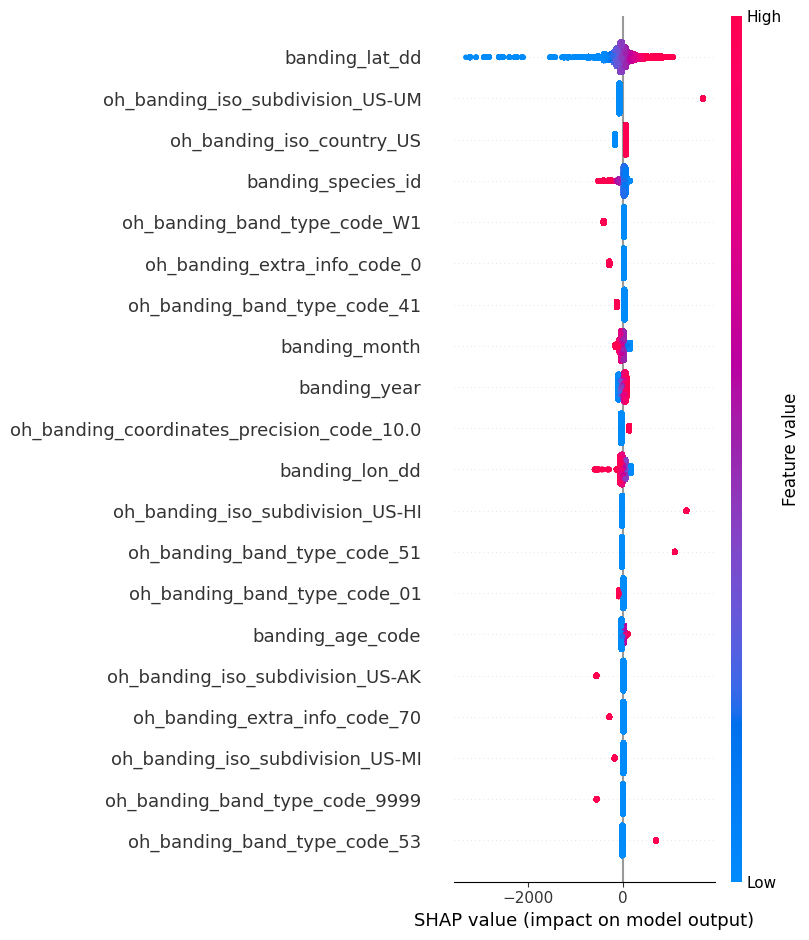

In [25]:
# show most infleuential features using shap
explainer = shap.Explainer(best_ols_model.named_steps['regressor'], 
                           best_ols_model.named_steps['scaler'].transform(X_train),
                           feature_names=X_train.columns.tolist())

shap_values = explainer(best_ols_model.named_steps['scaler'].transform(X_test))
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns.tolist())

In [22]:
# Use GridSearchCV to find best parms for SGDregressor also scaling all data except the target (event_days_span) and one hot encoded columns beginning with ("oh_")

modelfile = os.path.join(modelpath, "sgd_regression_best_model.pkl")

# if model file exists, load model from file, else run pipeline
if os.path.exists(modelfile):
    best_sgd_model = joblib.load(modelfile)
    print("Loaded model from file:", modelfile)
else:
    

    from sklearn.linear_model import SGDRegressor

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', SGDRegressor(random_state=1))
    ])



    # param_grid = {
    #     'regressor__loss': ['squared_loss', 'huber', 'epsilon_insensitive'],
    #     'regressor__penalty': ['l2', 'l1', 'elasticnet'],
    #     'regressor__alpha': [0.0001, 0.001, 0.01],
    #     'regressor__max_iter': [1000, 2000], 
    # }
    
    # Best Parameters: {'regressor__alpha': 0.0001, 'regressor__loss': 'epsilon_insensitive', 'regressor__max_iter': 1000, 'regressor__penalty': 'l1'}
    param_grid = {
        'regressor__loss': ['epsilon_insensitive'],
        'regressor__penalty': ['l1'],
        'regressor__alpha': [0.0001],
        'regressor__max_iter': [1000], 
    }

    scorer = make_scorer(mean_squared_error, greater_is_better=False)


    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scorer,
        cv=5,
        n_jobs=-1,
        verbose=2,
    )
    


    grid_search.fit(X_train_sample, y_train_sample) # Use sample for faster training
    #grid_search.fit(X_train, y_train)  # Use full training data # unable to use full due to crash beyond 1m sample # use same sample as linear regression


    best_sgd_model = grid_search.best_estimator_  # Fixed: variable name consistency
    # Save best model to file
    joblib.dump(best_sgd_model, modelfile)
    print("Saved best model to file:", modelfile)

    # Output best parameters and score
    print("Best Parameters:", grid_search.best_params_)
    print("Best Score:", grid_search.best_score_)




    # Evaluate best model on test set

y_pred = best_sgd_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("Hyperparams:", best_sgd_model.get_params())

print("Test MSE:", mse)
print("Test R2:", r2)
print("Test RMSE:", rmse)

Loaded model from file: ../data/models/sgd_regression_best_model.pkl
Hyperparams: {'memory': None, 'steps': [('scaler', StandardScaler()), ('regressor', SGDRegressor(loss='epsilon_insensitive', penalty='l1', random_state=1))], 'transform_input': None, 'verbose': False, 'scaler': StandardScaler(), 'regressor': SGDRegressor(loss='epsilon_insensitive', penalty='l1', random_state=1), 'scaler__copy': True, 'scaler__with_mean': True, 'scaler__with_std': True, 'regressor__alpha': 0.0001, 'regressor__average': False, 'regressor__early_stopping': False, 'regressor__epsilon': 0.1, 'regressor__eta0': 0.01, 'regressor__fit_intercept': True, 'regressor__l1_ratio': 0.15, 'regressor__learning_rate': 'invscaling', 'regressor__loss': 'epsilon_insensitive', 'regressor__max_iter': 1000, 'regressor__n_iter_no_change': 5, 'regressor__penalty': 'l1', 'regressor__power_t': 0.25, 'regressor__random_state': 1, 'regressor__shuffle': True, 'regressor__tol': 0.001, 'regressor__validation_fraction': 0.1, 'regresso

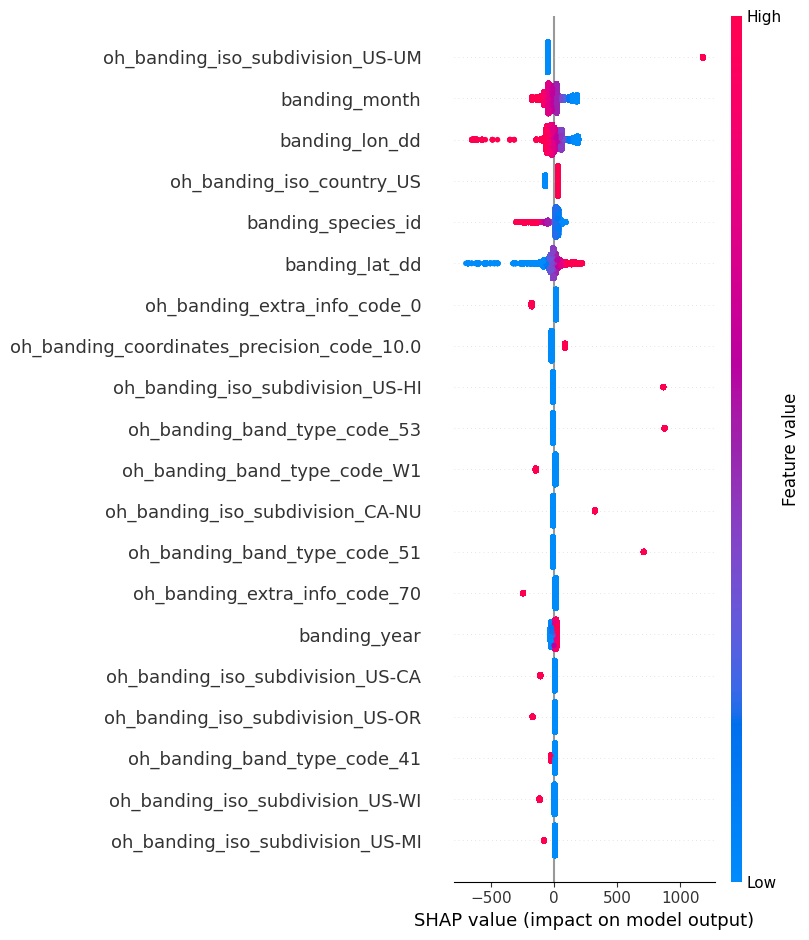

In [26]:
# show most influential features using shap
explainer = shap.Explainer(best_sgd_model.named_steps['regressor'], 
                           best_sgd_model.named_steps['scaler'].transform(X_train),
                           feature_names=X_train.columns.tolist())

shap_values = explainer(best_sgd_model.named_steps['scaler'].transform(X_test))
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns.tolist())

In [39]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import time

models = {
    'OLS': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=1.0))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Lasso(alpha=1.0, max_iter=5000))
    ]),
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000))
    ]),
    'SGD': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', SGDRegressor(max_iter=1000, random_state=1))
    ]),
    'RandomForest': RandomForestRegressor(
        n_estimators=100, 
        max_depth=15, 
        random_state=1, 
        n_jobs=-1
    )
}

results = []
for name, model in models.items():
    start_time = time.time()
    print(f"Training model: {name}")
    # Use full training data, not just sample
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    train_time = time.time() - start_time
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'R2': r2,
        'Train_Time_Sec': train_time
    })
    
results_df = pd.DataFrame(results).sort_values('RMSE')
print(results_df)


Training model: OLS
Training model: Ridge
Training model: Lasso
Training model: ElasticNet
Training model: SGD
Training model: RandomForest
          Model          RMSE            R2  Train_Time_Sec
5  RandomForest  1.081433e+03  2.775149e-01      369.300155
1         Ridge  1.159806e+03  1.690016e-01        8.603583
0           OLS  1.159806e+03  1.690016e-01       15.824919
2         Lasso  1.160029e+03  1.686817e-01       15.222318
3    ElasticNet  1.169657e+03  1.548253e-01        5.548477
4           SGD  2.247681e+11 -3.121037e+16      146.816679


In [ ]:
# analyze df contents
pd.set_option('display.max_columns', 50)
pd.set_option('display.width',1000)  
pd.set_option('display.max_rows', 300)


print(df_banding_pd.describe(include='all').transpose())

                                                count          mean          std     min     25%     50%     75%      max
banding_day                                 4432669.0  1.663499e+01     8.711529     1.0     9.0    17.0    24.0     31.0
banding_month                               4432669.0  6.755581e+00     2.309020     1.0     6.0     7.0     8.0     12.0
banding_year                                4432669.0  1.995383e+03    18.928453  1960.0  1979.0  1999.0  2012.0   2025.0
banding_species_id                          4432669.0  1.892055e+03  1303.513107    10.0  1320.0  1550.0  1720.0   8710.0
oh_banding_iso_country_AA                   4432669.0  1.353586e-06     0.001163     0.0     0.0     0.0     0.0      1.0
oh_banding_iso_country_AG                   4432669.0  1.376146e-05     0.003710     0.0     0.0     0.0     0.0      1.0
oh_banding_iso_country_AQ                   4432669.0  9.689422e-04     0.031113     0.0     0.0     0.0     0.0      1.0
oh_banding_iso_country_A